# Testing SST implementation of SHRED to understand

Dataset: Weekly mean sea-surface temperature as given by the NOAA Optimum Interpolation SST V2 dataset [[1]](https://psl.noaa.gov/data/gridded/data.noaa.oisst.v2.html)
- Note: this is anomaly data (the bulk mean value has been subtracted)

Code: Adapted from the example in pyshred [[2]](https://github.com/Jan-Williams/pyshred/blob/main/example.ipynb)

This notebook was used prior to understand the process prior developing the helper functions in Data.preprocess_sst_ofam3_shred

Hence, much of this code duplicates those functions functionality, but for the SST_data.mat file used in the paper

In [12]:
import numpy as np
import pandas as pd
import torch
from scipy.io import loadmat
from sklearn.preprocessing import MinMaxScaler

import models  # https://github.com/Jan-Williams/pyshred/blob/main/models.py
from Data.preprocess_sst_ofam3_shred import TimeSeriesDataset
from helper_functions.plotting_functions import plot_sst_map

### Load data

From Mobile-Sensor SHRED paper [[3]](https://ieeexplore.ieee.org/document/10584544):

Weekly mean SST from 1992 - 2019

1400 snapshots of a 180 x 360 grid, with landmass excluded leaves 44,219 spatial locations corresponding to the sea surface

In [ ]:
lat = np.arange(89.5, -90.0, -1.0)   # 180 points, descending: 89.5 to -89.5
lon = np.arange(0.5, 360.0, 1.0)     # 360 points: 0.5 to 359.5

# 2D meshgrid if you need lat/lon paired at every grid cell
lon2d, lat2d = np.meshgrid(lon, lat)  # shape (180, 360) each
longs = lon2d.reshape(-1)
lats = lat2d.reshape(-1)

# Use mask to remove land regions from the data
load_X = loadmat('Data/SST_data.mat')['Z'].T
mean_X = np.mean(load_X, axis=0)
ocean_idx = np.where(mean_X != 0)[0]

# Keep only the coordinates that correspond to the ocean points
longs = longs[ocean_idx]
lats = lats[ocean_idx]

# Keep the SST data aligned with those coordinates
data = load_X[:, ocean_idx]

print(data.shape, len(longs), len(lats))

(1400, 44219) 44219 44219


In [17]:
n = data.shape[0]  # Number of snapshots
m = data.shape[1]  # Number of spatial locations

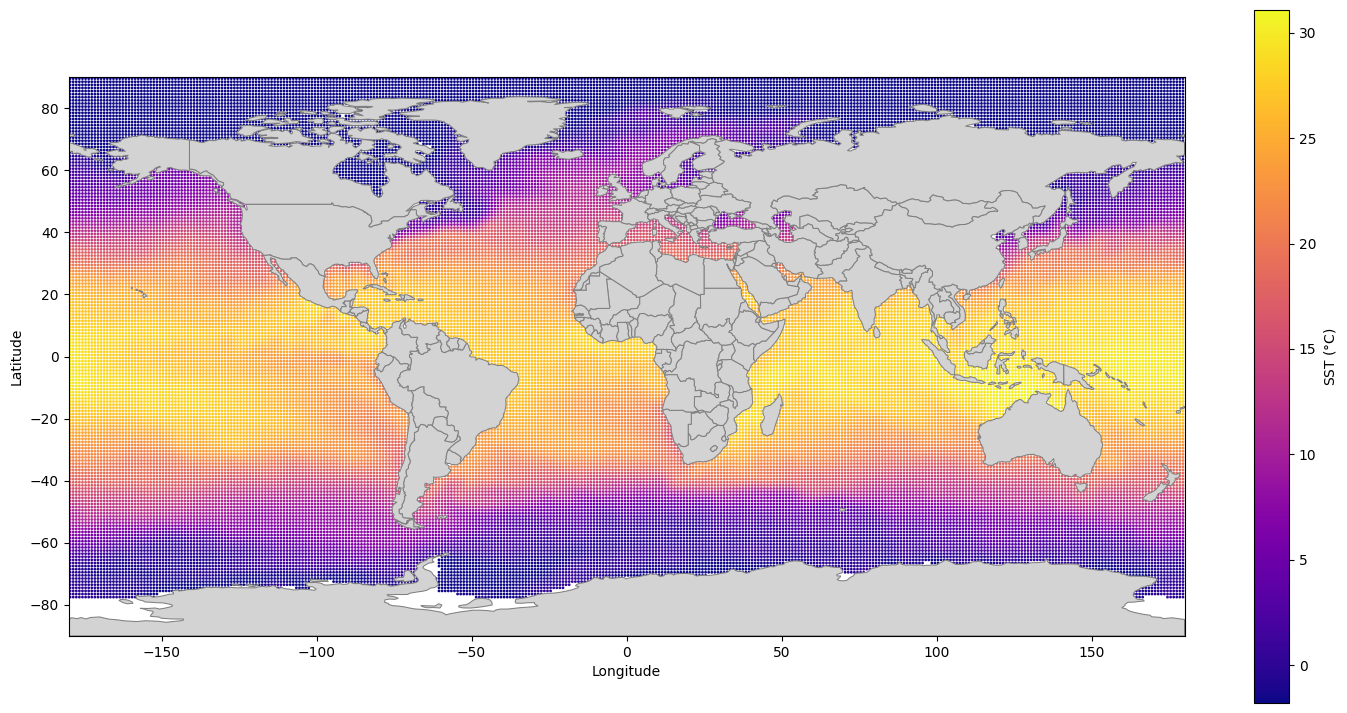

In [20]:
df = pd.DataFrame({"Longitude": longs, "Latitude": lats, "SST": data[0]})
# Convert longitude to -180 to 180 format, allows plotting against geopandas world maps
df['Longitude'] = df['Longitude'].apply(lambda x: -(360-x) if x > 180 else x)

plot_sst_map(df)


### Preprocess
Choose 3 sensor locations randomly

In [ ]:
num_sensors = 3
lags = 52  # one year of measurements
sensor_locations = np.random.choice(m, size=num_sensors, replace=False)  # Pick three locations from the m locations in the dataset
sensor_locations

Select indices to divide the data into training, validation, and test sets

get 1000 training snapshots, 174 test and 174 validation snapshots. Randomly chosen across entire dataset - not done by time.

In [ ]:
train_indices = np.random.choice(n - lags, size=1000, replace=False)
mask = np.ones(n - lags)
mask[train_indices] = 0
valid_test_indices = np.arange(0, n - lags)[np.where(mask!=0)[0]]
valid_indices = valid_test_indices[::2]
test_indices = valid_test_indices[1::2]

For training: use MinMaxScaler() on training data (normalisation step)

In [ ]:
sc = MinMaxScaler()
sc = sc.fit(data[train_indices])  # Computes min and max from training data only
transformed_X = sc.transform(data)  # Normalises data

Organize the data such that the inputs are of shape (batch_size, lags, num_sensors) with corresponding outputs of size (batch_size, state_dimension)

In [ ]:
# Generate input sequences to a SHRED model
all_data_in = np.zeros((n - lags, lags, num_sensors))
for i in range(len(all_data_in)):
    all_data_in[i] = transformed_X[i:i+lags, sensor_locations]  # stores values between i and 52 weeks, at 3 sensor locations

In [ ]:
print(len(all_data_in))  # Number of sequences
print(len(all_data_in[0]))  # sequences of 52 weeks
print(len(all_data_in[0][0]))  # 3 sensor locations

In [ ]:
### Generate training validation and test datasets both for reconstruction of states and forecasting sensors
device = 'cuda' if torch.cuda.is_available() else 'cpu'

train_data_in = torch.tensor(all_data_in[train_indices], dtype=torch.float32).to(device)
valid_data_in = torch.tensor(all_data_in[valid_indices], dtype=torch.float32).to(device)
test_data_in = torch.tensor(all_data_in[test_indices], dtype=torch.float32).to(device)

### -1 to have output be at the same time as final sensor measurements
train_data_out = torch.tensor(transformed_X[train_indices + lags - 1], dtype=torch.float32).to(device)
valid_data_out = torch.tensor(transformed_X[valid_indices + lags - 1], dtype=torch.float32).to(device)
test_data_out = torch.tensor(transformed_X[test_indices + lags - 1], dtype=torch.float32).to(device)

train_dataset = TimeSeriesDataset(train_data_in, train_data_out)
valid_dataset = TimeSeriesDataset(valid_data_in, valid_data_out)
test_dataset = TimeSeriesDataset(test_data_in, test_data_out)

Pass in a sequence of 52 week measurements for 3 sensor locations

In [ ]:
print(len(train_data_in))  # Number of sequences
print(len(train_data_in[0]))  # sequences of 52 weeks
print(len(train_data_in[0][0]))  # 3 sensor locations
print(train_data_in.shape)

Want model to predict entire spatial field from the 52 weeks at 3 sensor locations

To do this, pass it the true data to learn from as labels

In [ ]:
print(len(train_data_out))  # Number of sequences
print(len(train_data_out[0]))  # Number of spatial locations
print(train_data_out.shape)

In [ ]:
shred = models.SHRED(num_sensors, m, hidden_size=64, hidden_layers=2, l1=350, l2=400, dropout=0.1).to(device)
validation_errors = models.fit(shred, train_dataset, valid_dataset, batch_size=64, num_epochs=1000, lr=1e-3, verbose=True, patience=5)

In [ ]:
test_recons = sc.inverse_transform(shred(test_dataset.X).detach().cpu().numpy())
test_ground_truth = sc.inverse_transform(test_dataset.Y.detach().cpu().numpy())
print('Test Reconstruction Error: ')
print(np.linalg.norm(test_recons - test_ground_truth) / np.linalg.norm(test_ground_truth))

In [ ]:
test_recons

Spatial Coverage [[1]](https://psl.noaa.gov/data/gridded/data.noaa.oisst.v2.html):

1.0 degree latitude x 1.0 degree longitude global grid (180x360).
89.5N - 89.5S, 0.5E - 359.5E.

BUT we don't know how the dataset was made... and hence exactly what coordinates correspond to each point...